In [1]:
#Librerías
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

np.random.seed(10)   # Para que siempre genere los mismos bits

In [2]:
# Configuración de parametros de la simulación:
# Orden de modulación
# 4  -> QPSK
# 16 -> 16QAM
M = 4
N = 64 # Número de subportadoras OFDM
CP = 16 # Longitud del prefijo cíclico
N_OFDM = 500 # Cantidad de símbolos OFDM
k = int(np.log2(M)) # Bits por símbolo
# Cantidad total de bits
N_BITS = N * N_OFDM * k

In [3]:
#Generación de bits:
bits_tx = np.random.randint(0,2,N_BITS)
print("Bits generados:", len(bits_tx))
print("Primeros 10 bits generados:", bits_tx[:10])

Bits generados: 64000
Primeros 10 bits generados: [1 1 0 1 0 1 1 0 1 1]


In [4]:
#Modulador: Convierte bits en símbolos complejos. QPSK o 16QAM
def modulator(bits, M):

    k = int(np.log2(M))
    bits = bits.reshape((-1,k)) #reshape genera matriz de bits de k columnas

    if M == 4: # QPSK
        constellation = {
            (0,0): 1+1j,
            (0,1): -1+1j,
            (1,1): -1-1j,
            (1,0): 1-1j
        }
        symbols = []
        for b in bits:
            symbol = constellation[tuple(b)]
            symbols.append(symbol)
        symbols = np.array(symbols) 
        # array de NumPy, permite hacer operaciones matemáticas sobre todos los elementos simultáneamente

        return symbols/np.sqrt(2) # Normalización

    elif M == 16: # 16QAM
        level = {
            (0,0):-3,
            (0,1):-1,
            (1,1):1,
            (1,0):3
        }
        symbols=[]
        for b in bits:
            I = level[tuple(b[:2])]
            Q = level[tuple(b[2:])]
            symbols.append(I + 1j*Q)

        return np.array(symbols)/np.sqrt(10) # Normalización
    
    else:
        raise ValueError("Modulación no soportada")

In [5]:
#Demodulador
def demodulator(symbols,M):
    bits=[]
    if M==4:
        symbols = symbols*np.sqrt(2)
        for s in symbols:
            I=s.real
            Q=s.imag

            if I>=0 and Q>=0:
                bits.extend([0,0])

            elif I<0 and Q>=0:
                bits.extend([0,1])

            elif I<0 and Q<0:
                bits.extend([1,1])

            else:
                bits.extend([1,0])

    elif M==16:
        symbols = symbols*np.sqrt(10)
        for s in symbols:
            I=s.real
            Q=s.imag

            # I
            if I<-2:
                bits.extend([0,0])
            elif I<0:
                bits.extend([0,1])
            elif I<2:
                bits.extend([1,1])
            else:
                bits.extend([1,0])

            # Q
            if Q<-2:
                bits.extend([0,0])
            elif Q<0:
                bits.extend([0,1])
            elif Q<2:
                bits.extend([1,1])
            else:
                bits.extend([1,0])

    return np.array(bits)

In [6]:
# FUNCIONES OFDM
def serial_to_parallel(symbols, N):
    """
    Convierte un vector de símbolos en una matriz.

    Cada fila representa un símbolo OFDM.
    Cada columna representa una subportadora.

            Serie

    x1 x2 x3 ... x64 x65 ...

            ↓

    | x1  x2 ... x64 |
    | x65 .........  |
    | ...            |

    """

    return symbols.reshape((-1, N))


def parallel_to_serial(matrix):
    """
    Convierte una matriz nuevamente en un vector.
    """

    return matrix.reshape(-1)


def add_cp(ofdm_symbol, CP):
    """
    Agrega el prefijo cíclico.
    OFDM:
    |---------------------------|
          64 muestras
    CP:
    |----|----------------------|
      16       64
    """
    cp = ofdm_symbol[-CP:]
    return np.concatenate((cp, ofdm_symbol))    

def remove_cp(ofdm_symbol, CP):
    """
    Elimina el prefijo cíclico.
    """
    return ofdm_symbol[CP:]

In [7]:
# TRANSMISOR OFDM
def ofdm_transmitter(symbols, N, CP):
    """
    Transmisor OFDM.
    Etapas:
        Serie → Paralelo
        IFFT
        Agregar CP
        Paralelo → Serie
    """
    # Serie -> Paralelo
    symbols_matrix = serial_to_parallel(symbols, N)
    tx_signal = []

    # Procesar cada símbolo OFDM
    for block in symbols_matrix:
        # Dominio del tiempo

        # Implementación con fast Fourier transform (IFFT)
        time_signal = np.fft.ifft(block)

        # Agregar prefijo cíclico
        time_signal = add_cp(time_signal, CP)
        tx_signal.extend(time_signal)

    return np.array(tx_signal)

In [8]:
# MODULACIÓN
symbols_tx = modulator(bits_tx, M)
print("Cantidad de símbolos:", len(symbols_tx))

# OFDM
tx_signal = ofdm_transmitter(symbols_tx, N, CP)

print("Longitud de la señal transmitida:", len(tx_signal))

Cantidad de símbolos: 32000
Longitud de la señal transmitida: 40000


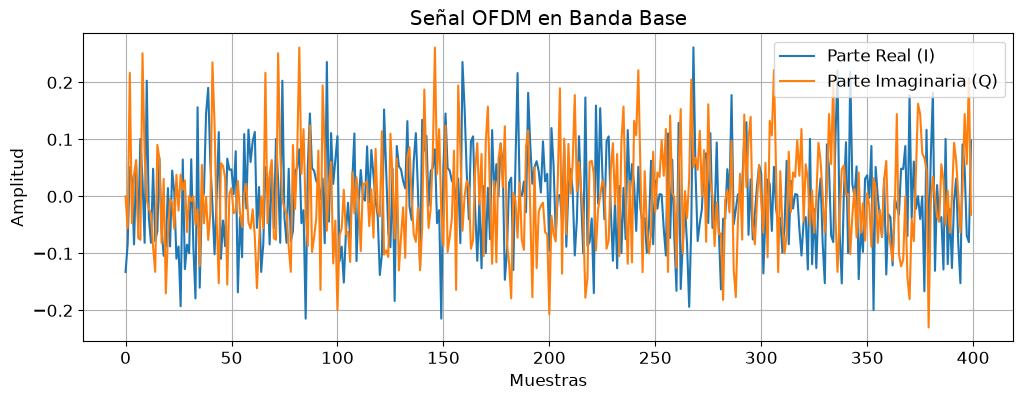

In [9]:
#Visualización de la señal transmitida
plt.figure(figsize=(12,4))

plt.plot(np.real(tx_signal[:400]), label="Parte Real (I)")
plt.plot(np.imag(tx_signal[:400]), label="Parte Imaginaria (Q)")

plt.title("Señal OFDM en Banda Base")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")

plt.grid(True)
plt.legend()

plt.show()

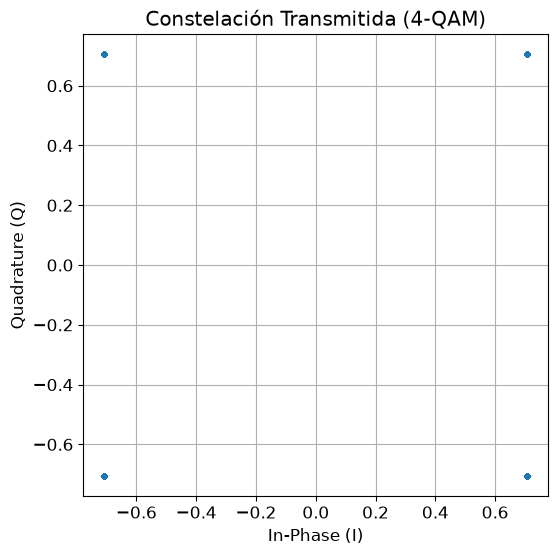

In [10]:
#Constelación transmitida
plt.figure(figsize=(6,6))

plt.scatter(symbols_tx.real,
            symbols_tx.imag,
            s=8)

plt.grid(True)

plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")

plt.title(f"Constelación Transmitida ({M}-QAM)")

plt.axis("equal")

plt.show()

In [11]:
# RUIDO BLANCO GAUSSIANO (AWGN)

def generate_awgn(signal, snr_db):
    """
    Genera ruido blanco gaussiano complejo para una
    determinada relación señal/ruido (SNR).

    Parámetros
    ----------
    signal : ndarray
        Señal transmitida.

    snr_db : float
        Relación señal/ruido en dB.

    Retorna
    -------
    noise : ndarray
        Ruido complejo.
    """

    # Potencia promedio de la señal
    signal_power = np.mean(np.abs(signal)**2)

    # Convertimos SNR de dB a escala lineal
    snr_linear = 10**(snr_db / 10)

    # Potencia que debe tener el ruido
    noise_power = signal_power / snr_linear

    # Ruido gaussiano complejo
    #
    # Se divide por sqrt(2) porque tenemos dos
    # componentes independientes:
    #
    #   I -> ruido real
    #   Q -> ruido imaginario
    #
    noise = np.sqrt(noise_power / 2) * (
        np.random.randn(len(signal))
        + 1j * np.random.randn(len(signal))
    )
    return noise

In [12]:
# CANAL CON RUIDO BLANCO

def noisy_channel(tx_signal, snr_db):
    """
    Canal AWGN.

    La señal transmitida atraviesa un canal ideal
    y se le agrega ruido blanco gaussiano.

        x(t) ───────► (+) ───────► y(t)
                       ▲
                       │
                     ruido
    """

    # Generar ruido
    noise = generate_awgn(tx_signal, snr_db)

    # Señal recibida
    rx_signal = tx_signal + noise

    return rx_signal

In [13]:
# CANAL
def ideal_channel(tx_signal):
    """
    Canal ideal.
    No modifica la señal.
    """
    return tx_signal.copy()

In [14]:
# RECEPTOR OFDM
def ofdm_receiver(rx_signal, N, CP):
    """
    Receptor OFDM.
    Etapas:
        Serie -> Paralelo
        Eliminar CP
        FFT
        Paralelo -> Serie
    """
    symbol_length = N + CP
    n_symbols = len(rx_signal) // symbol_length
    received_symbols = []
    for i in range(n_symbols):
        # Extraer un símbolo OFDM
        start = i * symbol_length
        end = start + symbol_length
        block = rx_signal[start:end]

        # Eliminar prefijo cíclico
        block = remove_cp(block, CP)

        # Volver al dominio de la frecuencia
        freq_signal = np.fft.fft(block)

        received_symbols.extend(freq_signal)
    return np.array(received_symbols)

In [15]:
#Recepción
# CANAL
# rx_signal = ideal_channel(tx_signal)
# PRUEBA DEL CANAL CON RUIDO BLANCO
SNR = 10  # dB
rx_signal = noisy_channel(tx_signal, SNR)

print(f"SNR = {SNR} dB")
# RECEPTOR OFDM
symbols_rx = ofdm_receiver(rx_signal, N, CP)

print("Cantidad de símbolos recibidos:", len(symbols_rx))

SNR = 10 dB
Cantidad de símbolos recibidos: 32000


In [16]:
# DEMODULACIÓN
bits_rx = demodulator(symbols_rx, M)

print("Bits recibidos:", len(bits_rx))

Bits recibidos: 64000


In [17]:
# BIT ERROR RATE

bit_errors = np.sum(bits_tx != bits_rx)
ber = bit_errors / len(bits_tx)

print("="*40)
print("RESULTADOS")
print("="*40)

print(f"Bits transmitidos : {len(bits_tx)}")
print(f"Bits erróneos     : {bit_errors}")
print(f"BER               : {ber:.6e}")

RESULTADOS
Bits transmitidos : 64000
Bits erróneos     : 48
BER               : 7.500000e-04


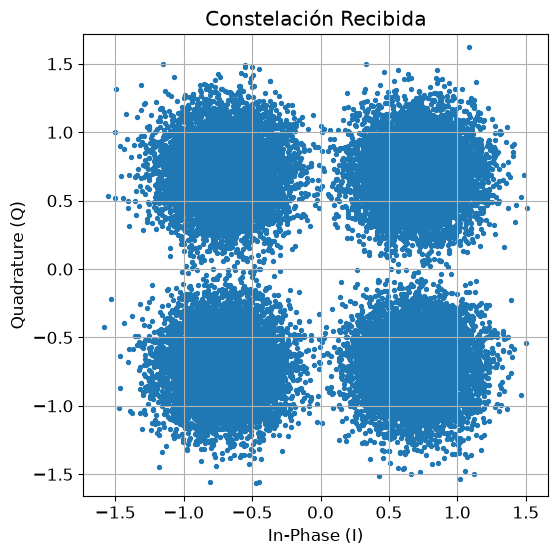

In [18]:
#Constelación recibida
plt.figure(figsize=(6,6))
plt.scatter(
    symbols_rx.real,
    symbols_rx.imag,
    s=8
)
plt.grid(True)
plt.xlabel("In-Phase (I)")
plt.ylabel("Quadrature (Q)")
plt.title("Constelación Recibida")
plt.axis("equal")
plt.show()

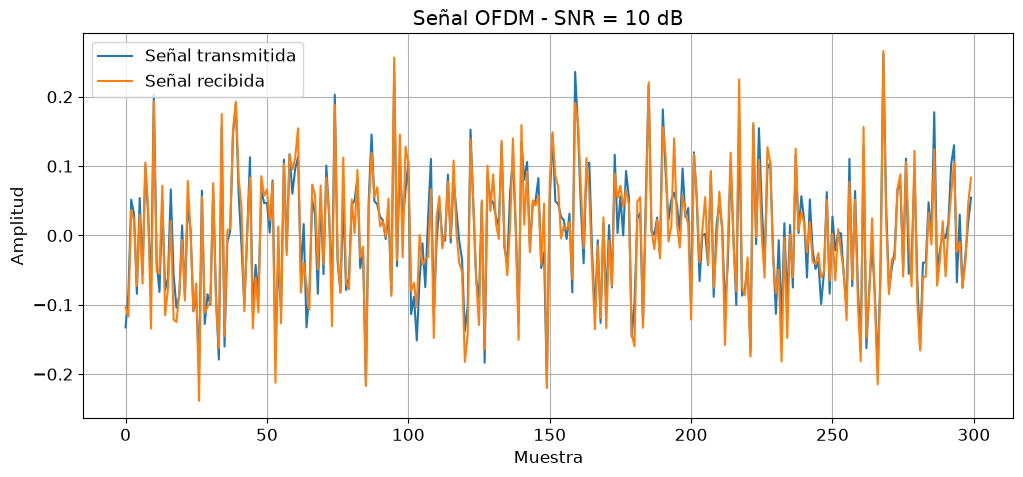

In [19]:
# ======================================================
# SEÑAL TRANSMITIDA VS RECIBIDA
# ======================================================

samples = 300

plt.figure(figsize=(12, 5))

plt.plot(
    np.real(tx_signal[:samples]),
    label="Señal transmitida"
)

plt.plot(
    np.real(rx_signal[:samples]),
    label="Señal recibida"
)

plt.xlabel("Muestra")
plt.ylabel("Amplitud")

plt.title(f"Señal OFDM - SNR = {SNR} dB")

plt.grid(True)
plt.legend()

plt.show()